# Experimentos avanzados (ronda 2)

Continúa `03_model_experiments.ipynb` con cuatro frentes adicionales, elegidos
explícitamente:

1. **Más árboles ensamblados**: XGBoost y LightGBM, con categóricas nativas
   (sin one-hot), y ajuste de hiperparámetros con **validación cruzada**
   (`RandomizedSearchCV` con `StratifiedKFold`) para las familias líderes
   (HistGradientBoosting, XGBoost, LightGBM y CatBoost).
2. **CatBoost con Focal Loss**, para comparar contra `auto_class_weights`
   como estrategia de desbalance.
3. **Calibración de probabilidades** (isotónica y sigmoide) del mejor
   candidato, con curva de confiabilidad.
4. **Análisis de costo**: sensibilidad del umbral óptimo a distintos
   supuestos de costo relativo falso negativo / falso positivo, como
   alternativa al umbral que maximiza F1.

Reutiliza el mismo dataset, split y *feature engineering* que
`03_model_experiments.ipynb`, y registra todo en el mismo experimento de
MLflow (`online-shoppers-purchase-intention-experiments`) para que las 39
corridas anteriores y las de aquí queden comparables entre sí.

> **Nota sobre el test set**: `03_model_experiments.ipynb` ya evaluó su
> campeón sobre test una vez. Si en esta ronda aparece un candidato que
> supera a ese campeón en F1 de *validación*, se evalúa sobre test una
> segunda vez al final, pero ese resultado debe leerse como informativo,
> no como una estimación insesgada: mirar el test más de una vez durante
> la experimentación infla el optimismo de la selección. Si ningún
> candidato nuevo supera al campeón anterior, el test no se vuelve a tocar.


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.catboost
import mlflow.lightgbm
import mlflow.sklearn
import mlflow.xgboost
import numpy as np
import os
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

from online_shoppers.data import (
    CATEGORICAL_COLUMNS,
    CONTINUOUS_COLUMNS,
    COUNT_COLUMNS,
    TARGET_COLUMN,
    load_dataset,
)
from online_shoppers.modeling import evaluate_probabilities, select_f1_threshold, split_dataset
from online_shoppers.tracking import tracked_run

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
DATA_PATH = ROOT / "data/raw/online_shoppers_intention.csv"
PRODUCTION_METRICS_PATH = ROOT / "reports/model_metrics.json"
PREVIOUS_EXPERIMENT_SUMMARY_PATH = ROOT / "reports/experiments/model_metrics_experiments.json"
FIGURES_DIR = ROOT / "notebooks/reports/figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", f"sqlite:///{ROOT / 'mlflow.db'}")
EXPERIMENT_NAME = "online-shoppers-purchase-intention-experiments"
RANDOM_SEED = 42

sessions = load_dataset(DATA_PATH)
splits = split_dataset(sessions, random_seed=RANDOM_SEED)
train, validation, test = splits.train, splits.validation, splits.test
y_train, y_validation, y_test = train[TARGET_COLUMN], validation[TARGET_COLUMN], test[TARGET_COLUMN]

previous_summary = json.loads(PREVIOUS_EXPERIMENT_SUMMARY_PATH.read_text())
previous_champion_run = previous_summary["champion_run"]
previous_validation_f1 = previous_summary["validation_metrics"]["f1"]
previous_test_f1 = previous_summary["test_metrics"]["f1"]
previous_champion_run, previous_validation_f1, previous_test_f1


/Users/adrianalarcon/Documents/uniandes/maia_despliegue_soluciones_microproyecto/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


('stacking_trees__engineered_full', 0.6863270777479893, 0.6737967914438503)

## Preparación: mismo *feature engineering* que en 03

Se repite exactamente la misma lógica (mismas 5 variantes de variables) para
que los resultados de esta ronda sean comparables con la anterior sin
depender de reejecutar ese notebook.


In [2]:
def _bucket_traffic_type(traffic_type: pd.Series, frequent_codes: set[int]) -> pd.Series:
    return traffic_type.where(traffic_type.isin(frequent_codes), other=-1).astype(str)


def engineer_features(frame: pd.DataFrame, frequent_traffic_types: set[int]) -> pd.DataFrame:
    """Add row-level engineered features with no target leakage."""

    engineered = frame.copy()
    total_duration = (
        engineered["Administrative_Duration"]
        + engineered["Informational_Duration"]
        + engineered["ProductRelated_Duration"]
    )
    total_pageviews = (
        engineered["Administrative"] + engineered["Informational"] + engineered["ProductRelated"]
    )
    engineered["total_duration"] = total_duration
    engineered["total_pageviews"] = total_pageviews
    engineered["avg_duration_per_page"] = (
        (total_duration / total_pageviews).replace([np.inf, -np.inf], 0).fillna(0)
    )
    engineered["admin_duration_share"] = (
        (engineered["Administrative_Duration"] / total_duration)
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
    )
    engineered["product_duration_share"] = (
        (engineered["ProductRelated_Duration"] / total_duration)
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
    )
    engineered["bounce_exit_gap"] = engineered["ExitRates"] - engineered["BounceRates"]
    engineered["engagement_score"] = engineered["ProductRelated_Duration"] * (
        1 - engineered["ExitRates"]
    )
    engineered["page_values_log"] = np.log1p(engineered["PageValues"])
    engineered["product_related_duration_log"] = np.log1p(engineered["ProductRelated_Duration"])
    engineered["has_special_day"] = (engineered["SpecialDay"] > 0).astype(int)
    engineered["month_quarter"] = np.where(
        engineered["Month"].isin(["Nov", "Dec"]), "holiday_peak", "regular"
    )
    engineered["traffic_type_grouped"] = _bucket_traffic_type(
        engineered["TrafficType"], frequent_traffic_types
    )
    engineered["is_weekend_returning"] = (
        engineered["Weekend"] & (engineered["VisitorType"] == "Returning_Visitor")
    ).astype(str)
    return engineered


traffic_counts = train["TrafficType"].value_counts()
FREQUENT_TRAFFIC_TYPES = set(traffic_counts[traffic_counts >= 200].index)

train_fe = engineer_features(train, FREQUENT_TRAFFIC_TYPES)
validation_fe = engineer_features(validation, FREQUENT_TRAFFIC_TYPES)
test_fe = engineer_features(test, FREQUENT_TRAFFIC_TYPES)

ENGINEERED_NUMERIC = [
    "total_duration",
    "total_pageviews",
    "avg_duration_per_page",
    "admin_duration_share",
    "product_duration_share",
    "bounce_exit_gap",
    "engagement_score",
    "page_values_log",
    "product_related_duration_log",
    "has_special_day",
]
ENGINEERED_CATEGORICAL = ["month_quarter", "traffic_type_grouped", "is_weekend_returning"]

BASE_NUMERIC = [*COUNT_COLUMNS, *CONTINUOUS_COLUMNS]
BASE_CATEGORICAL = list(CATEGORICAL_COLUMNS)
NOISY_CATEGORICAL = ["OperatingSystems", "Browser", "Region"]

FEATURE_SETS: dict[str, dict[str, list[str]]] = {
    "base_with_page_values": {"numeric": BASE_NUMERIC, "categorical": BASE_CATEGORICAL},
    "base_without_page_values": {
        "numeric": [c for c in BASE_NUMERIC if c != "PageValues"],
        "categorical": BASE_CATEGORICAL,
    },
    "engineered_full": {
        "numeric": BASE_NUMERIC + ENGINEERED_NUMERIC,
        "categorical": BASE_CATEGORICAL + ENGINEERED_CATEGORICAL,
    },
    "engineered_reduced": {
        "numeric": BASE_NUMERIC + ENGINEERED_NUMERIC,
        "categorical": [c for c in BASE_CATEGORICAL if c not in NOISY_CATEGORICAL]
        + ENGINEERED_CATEGORICAL,
    },
    "engineered_without_page_values": {
        # page_values_log is log1p(PageValues): for a tree-based split it carries
        # essentially the same information as PageValues, so it must be excluded
        # too, or this variant would not actually be free of that signal.
        "numeric": [
            c
            for c in BASE_NUMERIC + ENGINEERED_NUMERIC
            if c not in ("PageValues", "page_values_log")
        ],
        "categorical": BASE_CATEGORICAL + ENGINEERED_CATEGORICAL,
    },
}
ALL_CATEGORICAL_COLUMNS = sorted({*BASE_CATEGORICAL, *ENGINEERED_CATEGORICAL})
list(FEATURE_SETS)


['base_with_page_values',
 'base_without_page_values',
 'engineered_full',
 'engineered_reduced',
 'engineered_without_page_values']

## Infraestructura común

Además de lo ya usado en 03 (preprocesador OHE+escala para modelos
scikit-learn, manejo nativo de categóricas para CatBoost), se agrega:

- `CATEGORICAL_DTYPES`: el dominio de categorías de cada columna categórica
  se calcula sobre la unión de train + validación + test (solo sobre las
  variables, sin usar el target — no hay fuga), y se aplica igual en los
  tres splits. Es necesario para XGBoost/LightGBM: si cada split convierte a
  `category` por separado, pandas puede asignarle códigos internos distintos
  a la misma categoría en train vs. validación/test y el modelo quedaría mal
  alineado en inferencia.
- Ayudantes para entrenar XGBoost y LightGBM con categóricas nativas y
  *early stopping*.
- Ayudantes de ajuste con validación cruzada: `RandomizedSearchCV` para las
  familias compatibles con `sklearn.base.clone` (HistGradientBoosting,
  XGBoost, LightGBM) y una búsqueda manual por *k-fold* para CatBoost, cuyo
  envoltorio de scikit-learn no soporta `clone()` cuando `cat_features` está
  fijo en el constructor.


In [3]:
def build_generic_preprocessor(
    numeric_columns: list[str], categorical_columns: list[str]
) -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline([("scale", StandardScaler())]), numeric_columns),
            (
                "categorical",
                Pipeline([("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                categorical_columns,
            ),
        ],
        remainder="drop",
    )


def _categorical_dtype_for(column: str) -> pd.CategoricalDtype:
    categories = sorted(
        set(train_fe[column].astype(str).unique())
        | set(validation_fe[column].astype(str).unique())
        | set(test_fe[column].astype(str).unique())
    )
    return pd.CategoricalDtype(categories=categories)


CATEGORICAL_DTYPES = {column: _categorical_dtype_for(column) for column in ALL_CATEGORICAL_COLUMNS}

RUN_LOG: list[dict[str, object]] = []
MODEL_REGISTRY: dict[str, dict[str, object]] = {}


def _log_candidate(
    run_name: str,
    params: dict[str, object],
    metrics: dict[str, float | int],
    threshold: float,
    *,
    log_model=None,
) -> None:
    with tracked_run(
        tracking_uri=TRACKING_URI,
        experiment_name=EXPERIMENT_NAME,
        run_name=run_name,
        params=params,
    ):
        mlflow.log_metrics({f"validation_{key}": float(value) for key, value in metrics.items()})
        mlflow.log_metric("threshold", threshold)
        if log_model is not None:
            log_model()
    RUN_LOG.append({"run_name": run_name, **params, **metrics, "threshold": threshold})


def _feature_columns(feature_set_name: str) -> list[str]:
    columns = FEATURE_SETS[feature_set_name]
    return columns["numeric"] + columns["categorical"]


def _prepare_catboost_X(frame: pd.DataFrame, feature_set_name: str) -> pd.DataFrame:
    columns = FEATURE_SETS[feature_set_name]
    X = frame.loc[:, _feature_columns(feature_set_name)].copy()
    for column in columns["categorical"]:
        X[column] = X[column].astype(str)
    return X


def _prepare_native_categorical(frame: pd.DataFrame, feature_set_name: str) -> pd.DataFrame:
    columns = FEATURE_SETS[feature_set_name]
    X = frame.loc[:, _feature_columns(feature_set_name)].copy()
    for column in columns["categorical"]:
        X[column] = X[column].astype(str).astype(CATEGORICAL_DTYPES[column])
    return X


def sklearn_predict_proba(pipeline: Pipeline, feature_set_name: str, frame: pd.DataFrame) -> np.ndarray:
    return pipeline.predict_proba(frame.loc[:, _feature_columns(feature_set_name)])[:, 1]


def catboost_predict_proba(model, feature_set_name: str, frame: pd.DataFrame) -> np.ndarray:
    return model.predict_proba(_prepare_catboost_X(frame, feature_set_name))[:, 1]


def category_predict_proba(model, feature_set_name: str, frame: pd.DataFrame) -> np.ndarray:
    return model.predict_proba(_prepare_native_categorical(frame, feature_set_name))[:, 1]


def predict_proba_for_run(run_name: str, frame: pd.DataFrame) -> np.ndarray:
    entry = MODEL_REGISTRY[run_name]
    kind = entry["kind"]
    if kind == "sklearn":
        return sklearn_predict_proba(entry["object"], entry["feature_set"], frame)
    if kind == "catboost":
        return catboost_predict_proba(entry["object"], entry["feature_set"], frame)
    if kind in ("xgboost", "lightgbm"):
        return category_predict_proba(entry["object"], entry["feature_set"], frame)
    if kind == "calibrated":
        base_kind = entry["base_kind"]
        if base_kind == "sklearn":
            X = frame.loc[:, _feature_columns(entry["feature_set"])]
        elif base_kind == "catboost":
            X = _prepare_catboost_X(frame, entry["feature_set"])
        else:
            X = _prepare_native_categorical(frame, entry["feature_set"])
        return entry["object"].predict_proba(X)[:, 1]
    raise ValueError(f"unknown model kind for run {run_name!r}: {kind!r}")


SUMMARY_COLUMNS = [
    "run_name",
    "family",
    "model",
    "feature_set",
    "f1",
    "pr_auc",
    "roc_auc",
    "precision",
    "recall",
    "threshold",
]


def ranked_results() -> pd.DataFrame:
    results_df = pd.DataFrame(RUN_LOG)
    return results_df.loc[:, SUMMARY_COLUMNS].sort_values("f1", ascending=False).reset_index(drop=True)


def fit_sklearn_candidate(run_name, estimator, feature_set_name, *, extra_params=None, log_artifact=False):
    columns = FEATURE_SETS[feature_set_name]
    feature_columns = _feature_columns(feature_set_name)
    pipeline = Pipeline(
        [
            ("preprocess", build_generic_preprocessor(columns["numeric"], columns["categorical"])),
            ("classifier", estimator),
        ]
    )
    pipeline.fit(train_fe.loc[:, feature_columns], y_train)
    probabilities = sklearn_predict_proba(pipeline, feature_set_name, validation_fe)
    threshold = select_f1_threshold(y_validation.to_numpy(), probabilities)
    metrics = evaluate_probabilities(y_validation, probabilities, threshold)
    params = {
        "family": "sklearn",
        "model": type(estimator).__name__,
        "feature_set": feature_set_name,
        **(extra_params or {}),
    }
    log_model = (
        (lambda: mlflow.sklearn.log_model(pipeline, "model", serialization_format="pickle"))
        if log_artifact
        else None
    )
    _log_candidate(run_name, params, metrics, threshold, log_model=log_model)
    MODEL_REGISTRY[run_name] = {"kind": "sklearn", "feature_set": feature_set_name, "object": pipeline}
    return pipeline, metrics, threshold


def fit_catboost_candidate(
    run_name, feature_set_name, *, catboost_params=None, extra_params=None, log_artifact=False
):
    columns = FEATURE_SETS[feature_set_name]
    feature_columns = _feature_columns(feature_set_name)
    categorical_indices = [feature_columns.index(column) for column in columns["categorical"]]
    X_train_raw = _prepare_catboost_X(train_fe, feature_set_name)
    X_validation_raw = _prepare_catboost_X(validation_fe, feature_set_name)

    default_params: dict[str, object] = {
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 6,
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "auto_class_weights": "Balanced",
        "random_seed": RANDOM_SEED,
        "verbose": False,
        "allow_writing_files": False,
        "early_stopping_rounds": 50,
    }
    default_params.update(catboost_params or {})
    model = CatBoostClassifier(cat_features=categorical_indices, **default_params)
    model.fit(X_train_raw, y_train, eval_set=(X_validation_raw, y_validation))
    probabilities = catboost_predict_proba(model, feature_set_name, validation_fe)
    threshold = select_f1_threshold(y_validation.to_numpy(), probabilities)
    metrics = evaluate_probabilities(y_validation, probabilities, threshold)
    params = {
        "family": "catboost",
        "model": "CatBoostClassifier",
        "feature_set": feature_set_name,
        "iterations_used": model.tree_count_,
        **{k: v for k, v in default_params.items() if k not in {"verbose", "allow_writing_files"}},
        **(extra_params or {}),
    }
    log_model = (lambda: mlflow.catboost.log_model(model, "model")) if log_artifact else None
    _log_candidate(run_name, params, metrics, threshold, log_model=log_model)
    MODEL_REGISTRY[run_name] = {"kind": "catboost", "feature_set": feature_set_name, "object": model}
    return model, metrics, threshold


def fit_xgboost_candidate(run_name, feature_set_name, *, xgb_params=None, log_artifact=False):
    X_train_native = _prepare_native_categorical(train_fe, feature_set_name)
    X_validation_native = _prepare_native_categorical(validation_fe, feature_set_name)
    negative, positive = int((~y_train).sum()), int(y_train.sum())
    default_params: dict[str, object] = {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 6,
        "tree_method": "hist",
        "enable_categorical": True,
        "eval_metric": "logloss",
        "scale_pos_weight": negative / positive,
        "random_state": RANDOM_SEED,
        "early_stopping_rounds": 50,
    }
    default_params.update(xgb_params or {})
    model = XGBClassifier(**default_params)
    model.fit(X_train_native, y_train, eval_set=[(X_validation_native, y_validation)], verbose=False)
    probabilities = category_predict_proba(model, feature_set_name, validation_fe)
    threshold = select_f1_threshold(y_validation.to_numpy(), probabilities)
    metrics = evaluate_probabilities(y_validation, probabilities, threshold)
    params = {
        "family": "xgboost",
        "model": "XGBClassifier",
        "feature_set": feature_set_name,
        "best_iteration": int(getattr(model, "best_iteration", default_params["n_estimators"])),
        **default_params,
    }
    log_model = (lambda: mlflow.xgboost.log_model(model, "model")) if log_artifact else None
    _log_candidate(run_name, params, metrics, threshold, log_model=log_model)
    MODEL_REGISTRY[run_name] = {"kind": "xgboost", "feature_set": feature_set_name, "object": model}
    return model, metrics, threshold


def fit_lightgbm_candidate(run_name, feature_set_name, *, lgbm_params=None, log_artifact=False):
    columns = FEATURE_SETS[feature_set_name]
    X_train_native = _prepare_native_categorical(train_fe, feature_set_name)
    X_validation_native = _prepare_native_categorical(validation_fe, feature_set_name)
    default_params: dict[str, object] = {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": -1,
        "num_leaves": 31,
        "class_weight": "balanced",
        "random_state": RANDOM_SEED,
        "verbose": -1,
    }
    default_params.update(lgbm_params or {})
    model = LGBMClassifier(**default_params)
    model.fit(
        X_train_native,
        y_train,
        eval_set=[(X_validation_native, y_validation)],
        categorical_feature=columns["categorical"],
        callbacks=[early_stopping(stopping_rounds=50, verbose=False), log_evaluation(period=0)],
    )
    probabilities = category_predict_proba(model, feature_set_name, validation_fe)
    threshold = select_f1_threshold(y_validation.to_numpy(), probabilities)
    metrics = evaluate_probabilities(y_validation, probabilities, threshold)
    params = {
        "family": "lightgbm",
        "model": "LGBMClassifier",
        "feature_set": feature_set_name,
        "best_iteration": int(getattr(model, "best_iteration_", default_params["n_estimators"]) or 0),
        **{k: v for k, v in default_params.items() if k != "verbose"},
    }
    log_model = (lambda: mlflow.lightgbm.log_model(model, "model")) if log_artifact else None
    _log_candidate(run_name, params, metrics, threshold, log_model=log_model)
    MODEL_REGISTRY[run_name] = {"kind": "lightgbm", "feature_set": feature_set_name, "object": model}
    return model, metrics, threshold


## Experimento A — HistGradientBoosting, CatBoost, XGBoost y LightGBM sobre los 5 conjuntos de variables

Se refresca HistGradientBoosting y CatBoost (ya vistos en 03) junto con
XGBoost y LightGBM (nuevos), todos sobre los mismos cinco conjuntos de
variables, para tener en este notebook un punto de partida propio por
familia antes de ajustarlos con validación cruzada.


In [4]:
for feature_set_name in FEATURE_SETS:
    fit_sklearn_candidate(
        f"hist_gradient_boosting__{feature_set_name}",
        HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_SEED),
        feature_set_name,
    )
    fit_catboost_candidate(f"catboost__{feature_set_name}", feature_set_name)
    fit_xgboost_candidate(f"xgboost__{feature_set_name}", feature_set_name)
    fit_lightgbm_candidate(f"lightgbm__{feature_set_name}", feature_set_name)

ranked_results().head(20)


,run_name,family,model,feature_set,f1,pr_auc,roc_auc,precision,recall,threshold
0,hist_gradient_boosting__engineered_full,sklearn,HistGradientBoostingClassifier,engineered_full,0.685930,0.737829,0.927924,0.657831,0.716535,0.627264
1,hist_gradient_boosting__engineered_reduced,sklearn,HistGradientBoostingClassifier,engineered_reduced,0.684411,0.737866,0.929921,0.661765,0.708661,0.654818
2,catboost__engineered_full,catboost,CatBoostClassifier,engineered_full,0.676316,0.747106,0.932589,0.678100,0.674541,0.805363
3,catboost__base_with_page_values,catboost,CatBoostClassifier,base_with_page_values,0.675418,0.743695,0.931090,0.619256,0.742782,0.732879
4,lightgbm__engineered_reduced,lightgbm,LGBMClassifier,engineered_reduced,0.672634,0.734546,0.927817,0.655860,0.690289,0.646759
5,xgboost__engineered_full,xgboost,XGBClassifier,engineered_full,0.672414,0.713297,0.923152,0.633411,0.716535,0.548476
6,hist_gradient_boosting__base_with_page_values,sklearn,HistGradientBoostingClassifier,base_with_page_values,0.671736,0.728302,0.926877,0.649510,0.695538,0.669781
7,catboost__engineered_reduced,catboost,CatBoostClassifier,engineered_reduced,0.669014,0.574449,0.898908,0.605096,0.748031,0.515341
8,lightgbm__base_with_page_values,lightgbm,LGBMClassifier,base_with_page_values,0.668387,0.724327,0.924373,0.657360,0.679790,0.644308
9,xgboost__engineered_reduced,xgboost,XGBClassifier,engineered_reduced,0.664901,0.717594,0.924759,0.671123,0.658793,0.663145


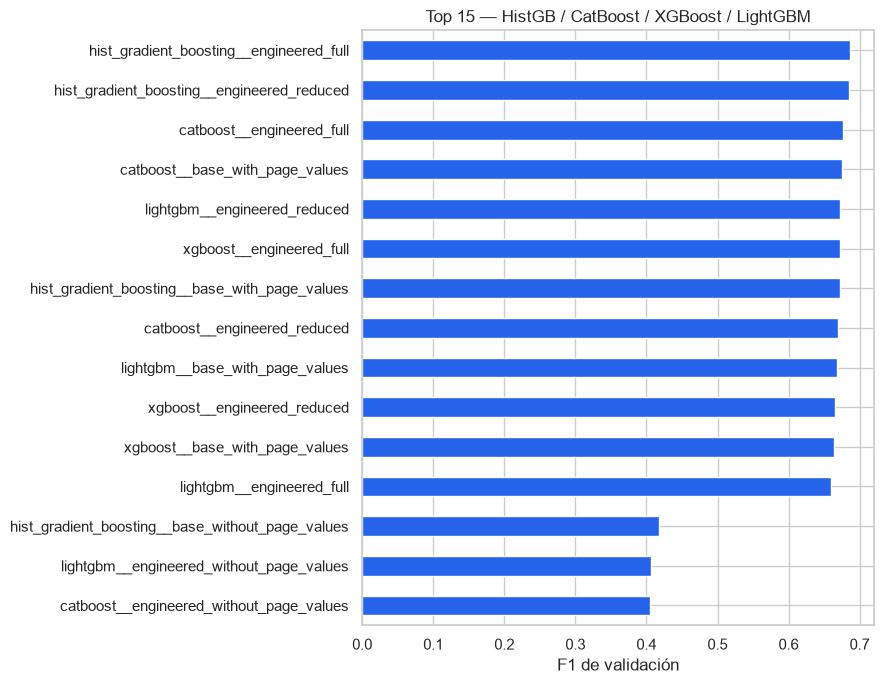

In [5]:
ranked = ranked_results()
fig, ax = plt.subplots(figsize=(9, 7))
ranked.head(15).set_index("run_name")["f1"].sort_values().plot.barh(ax=ax, color="#2563eb")
ax.set(title="Top 15 — HistGB / CatBoost / XGBoost / LightGBM", xlabel="F1 de validación", ylabel="")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "advanced_experiments_top_candidates.png", dpi=150)
plt.show()


## Experimento B — ajuste de hiperparámetros con validación cruzada

Para cada familia se usa el conjunto de variables donde obtuvo su mejor F1
en el experimento A, y se ajustan hiperparámetros con `StratifiedKFold(5)`
sobre train (F1 como métrica de selección, igual que en el resto del
notebook). HistGradientBoosting, XGBoost y LightGBM usan
`RandomizedSearchCV`; CatBoost usa una búsqueda manual equivalente porque su
envoltorio de scikit-learn no admite `clone()` con `cat_features` fijo.


In [6]:
def best_feature_set_for(family: str) -> str:
    family_rows = ranked[ranked["family"] == family]
    return str(family_rows.iloc[0]["feature_set"])


histgb_feature_set = best_feature_set_for("sklearn")
catboost_feature_set = best_feature_set_for("catboost")
xgboost_feature_set = best_feature_set_for("xgboost")
lightgbm_feature_set = best_feature_set_for("lightgbm")

CV_SPLITTER = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


def tune_sklearn_family(run_name, estimator, param_distributions, feature_set_name, *, n_iter=12, log_artifact=False):
    columns = FEATURE_SETS[feature_set_name]
    feature_columns = _feature_columns(feature_set_name)
    pipeline = Pipeline(
        [
            ("preprocess", build_generic_preprocessor(columns["numeric"], columns["categorical"])),
            ("classifier", estimator),
        ]
    )
    param_grid = {f"classifier__{key}": values for key, values in param_distributions.items()}
    search = RandomizedSearchCV(
        pipeline,
        param_grid,
        n_iter=n_iter,
        scoring="f1",
        cv=CV_SPLITTER,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        refit=True,
    )
    search.fit(train_fe.loc[:, feature_columns], y_train)
    best_pipeline = search.best_estimator_
    probabilities = sklearn_predict_proba(best_pipeline, feature_set_name, validation_fe)
    threshold = select_f1_threshold(y_validation.to_numpy(), probabilities)
    metrics = evaluate_probabilities(y_validation, probabilities, threshold)
    params = {
        "family": "sklearn",
        "model": type(estimator).__name__,
        "feature_set": feature_set_name,
        "tuned": "cv_random_search",
        "cv_best_f1": float(search.best_score_),
        **{key.replace("classifier__", ""): value for key, value in search.best_params_.items()},
    }
    log_model = (
        (lambda: mlflow.sklearn.log_model(best_pipeline, "model", serialization_format="pickle"))
        if log_artifact
        else None
    )
    _log_candidate(run_name, params, metrics, threshold, log_model=log_model)
    MODEL_REGISTRY[run_name] = {"kind": "sklearn", "feature_set": feature_set_name, "object": best_pipeline}
    return best_pipeline, metrics, threshold


def tune_native_family(
    run_name,
    build_estimator,
    param_distributions,
    feature_set_name,
    family_name,
    *,
    predict_fn,
    mlflow_log_model,
    n_iter=12,
    log_artifact=False,
):
    X_train_native = _prepare_native_categorical(train_fe, feature_set_name)
    search = RandomizedSearchCV(
        build_estimator(),
        param_distributions,
        n_iter=n_iter,
        scoring="f1",
        cv=CV_SPLITTER,
        random_state=RANDOM_SEED,
        n_jobs=1,
        refit=True,
    )
    search.fit(X_train_native, y_train)
    best_model = search.best_estimator_
    probabilities = predict_fn(best_model, feature_set_name, validation_fe)
    threshold = select_f1_threshold(y_validation.to_numpy(), probabilities)
    metrics = evaluate_probabilities(y_validation, probabilities, threshold)
    params = {
        "family": family_name,
        "model": type(best_model).__name__,
        "feature_set": feature_set_name,
        "tuned": "cv_random_search",
        "cv_best_f1": float(search.best_score_),
        **search.best_params_,
    }
    log_model = (lambda: mlflow_log_model(best_model)) if log_artifact else None
    _log_candidate(run_name, params, metrics, threshold, log_model=log_model)
    MODEL_REGISTRY[run_name] = {"kind": family_name, "feature_set": feature_set_name, "object": best_model}
    return best_model, metrics, threshold


def manual_cv_f1(build_model, X, y, cv):
    scores = []
    for train_idx, valid_idx in cv.split(X, y):
        model = build_model()
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        proba = model.predict_proba(X.iloc[valid_idx])[:, 1]
        scores.append(f1_score(y.iloc[valid_idx], proba >= 0.5, zero_division=0))
    return float(np.mean(scores))


tune_sklearn_family(
    f"hist_gradient_boosting_cv_tuned__{histgb_feature_set}",
    HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_SEED),
    {
        "max_iter": [100, 200, 300],
        "max_depth": [None, 3, 5, 7],
        "max_leaf_nodes": [15, 31, 63],
        "learning_rate": [0.03, 0.05, 0.1, 0.2],
        "l2_regularization": [0.0, 0.1, 1.0],
    },
    histgb_feature_set,
)

negative, positive = int((~y_train).sum()), int(y_train.sum())
tune_native_family(
    f"xgboost_cv_tuned__{xgboost_feature_set}",
    lambda: XGBClassifier(
        n_estimators=300,
        tree_method="hist",
        enable_categorical=True,
        scale_pos_weight=negative / positive,
        random_state=RANDOM_SEED,
    ),
    {
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.02, 0.05, 0.1],
        "min_child_weight": [1, 3, 5],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
    },
    xgboost_feature_set,
    "xgboost",
    predict_fn=category_predict_proba,
    mlflow_log_model=lambda model: mlflow.xgboost.log_model(model, "model"),
)

tune_native_family(
    f"lightgbm_cv_tuned__{lightgbm_feature_set}",
    lambda: LGBMClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_SEED, verbose=-1
    ),
    {
        "num_leaves": [15, 31, 63],
        "max_depth": [-1, 5, 7],
        "learning_rate": [0.02, 0.05, 0.1],
        "min_child_samples": [10, 20, 40],
        "subsample": [0.7, 0.85, 1.0],
    },
    lightgbm_feature_set,
    "lightgbm",
    predict_fn=category_predict_proba,
    mlflow_log_model=lambda model: mlflow.lightgbm.log_model(model, "model"),
)

CATBOOST_CV_GRID = [
    {"depth": 4, "learning_rate": 0.05, "l2_leaf_reg": 3},
    {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 3},
    {"depth": 6, "learning_rate": 0.1, "l2_leaf_reg": 5},
    {"depth": 8, "learning_rate": 0.03, "l2_leaf_reg": 3},
    {"depth": 8, "learning_rate": 0.05, "l2_leaf_reg": 7},
    {"depth": 8, "learning_rate": 0.1, "l2_leaf_reg": 1},
    {"depth": 10, "learning_rate": 0.03, "l2_leaf_reg": 5},
    {"depth": 10, "learning_rate": 0.05, "l2_leaf_reg": 7},
]
X_train_catboost = _prepare_catboost_X(train_fe, catboost_feature_set)
catboost_categorical_indices = [
    _feature_columns(catboost_feature_set).index(column)
    for column in FEATURE_SETS[catboost_feature_set]["categorical"]
]

catboost_cv_scores = []
for grid_params in CATBOOST_CV_GRID:

    def _build(grid_params=grid_params):
        return CatBoostClassifier(
            cat_features=catboost_categorical_indices,
            iterations=300,
            auto_class_weights="Balanced",
            random_seed=RANDOM_SEED,
            verbose=False,
            allow_writing_files=False,
            **grid_params,
        )

    catboost_cv_scores.append(manual_cv_f1(_build, X_train_catboost, y_train, CV_SPLITTER))

best_catboost_cv_index = int(np.argmax(catboost_cv_scores))
best_catboost_cv_params = CATBOOST_CV_GRID[best_catboost_cv_index]
best_catboost_cv_score = catboost_cv_scores[best_catboost_cv_index]

fit_catboost_candidate(
    f"catboost_cv_tuned__{catboost_feature_set}",
    catboost_feature_set,
    catboost_params={**best_catboost_cv_params, "iterations": 500},
    extra_params={"tuned": "cv_manual_grid", "cv_best_f1": best_catboost_cv_score},
)

ranked = ranked_results()
ranked.head(15)


,run_name,family,model,feature_set,f1,pr_auc,roc_auc,precision,recall,threshold
0,hist_gradient_boosting__engineered_full,sklearn,HistGradientBoostingClassifier,engineered_full,0.685930,0.737829,0.927924,0.657831,0.716535,0.627264
1,hist_gradient_boosting__engineered_reduced,sklearn,HistGradientBoostingClassifier,engineered_reduced,0.684411,0.737866,0.929921,0.661765,0.708661,0.654818
2,catboost_cv_tuned__engineered_full,catboost,CatBoostClassifier,engineered_full,0.681818,0.738442,0.931970,0.694823,0.669291,0.771409
3,catboost__engineered_full,catboost,CatBoostClassifier,engineered_full,0.676316,0.747106,0.932589,0.678100,0.674541,0.805363
4,catboost__base_with_page_values,catboost,CatBoostClassifier,base_with_page_values,0.675418,0.743695,0.931090,0.619256,0.742782,0.732879
5,hist_gradient_boosting_cv_tuned__engineered_full,sklearn,HistGradientBoostingClassifier,engineered_full,0.673826,0.722903,0.927102,0.689560,0.658793,0.668602
6,lightgbm__engineered_reduced,lightgbm,LGBMClassifier,engineered_reduced,0.672634,0.734546,0.927817,0.655860,0.690289,0.646759
7,xgboost__engineered_full,xgboost,XGBClassifier,engineered_full,0.672414,0.713297,0.923152,0.633411,0.716535,0.548476
8,hist_gradient_boosting__base_with_page_values,sklearn,HistGradientBoostingClassifier,base_with_page_values,0.671736,0.728302,0.926877,0.649510,0.695538,0.669781
9,lightgbm_cv_tuned__engineered_reduced,lightgbm,LGBMClassifier,engineered_reduced,0.669192,0.738751,0.929752,0.644769,0.695538,0.654854


## Experimento C — CatBoost con Focal Loss

Se compara `auto_class_weights="Balanced"` (usado hasta ahora) contra
`Focal Loss`, que penaliza más los ejemplos difíciles de clasificar en vez
de reponderar clases. Ambos parámetros son incompatibles entre sí en
CatBoost, así que Focal Loss se prueba sin `auto_class_weights`. Se usa el
mismo conjunto de variables donde CatBoost obtuvo su mejor resultado.


In [7]:
FOCAL_GRID = [(alpha, gamma) for alpha in (0.25, 0.5, 0.75) for gamma in (1.0, 2.0, 3.0)]
for alpha, gamma in FOCAL_GRID:
    fit_catboost_candidate(
        f"catboost_focal_a{alpha}_g{gamma}__{catboost_feature_set}",
        catboost_feature_set,
        catboost_params={
            "loss_function": f"Focal:focal_alpha={alpha};focal_gamma={gamma}",
            "auto_class_weights": None,
        },
        extra_params={"focal_alpha": alpha, "focal_gamma": gamma},
    )

ranked = ranked_results()
ranked.head(15)


,run_name,family,model,feature_set,f1,pr_auc,roc_auc,precision,recall,threshold
0,hist_gradient_boosting__engineered_full,sklearn,HistGradientBoostingClassifier,engineered_full,0.685930,0.737829,0.927924,0.657831,0.716535,0.627264
1,catboost_focal_a0.25_g2.0__engineered_full,catboost,CatBoostClassifier,engineered_full,0.684685,0.756511,0.936055,0.671717,0.698163,0.360410
2,hist_gradient_boosting__engineered_reduced,sklearn,HistGradientBoostingClassifier,engineered_reduced,0.684411,0.737866,0.929921,0.661765,0.708661,0.654818
3,catboost_cv_tuned__engineered_full,catboost,CatBoostClassifier,engineered_full,0.681818,0.738442,0.931970,0.694823,0.669291,0.771409
4,catboost_focal_a0.25_g3.0__engineered_full,catboost,CatBoostClassifier,engineered_full,0.680050,0.759557,0.935383,0.651442,0.711286,0.384393
5,catboost_focal_a0.75_g1.0__engineered_full,catboost,CatBoostClassifier,engineered_full,0.678529,0.748952,0.933696,0.619048,0.750656,0.543513
6,catboost_focal_a0.25_g1.0__engineered_full,catboost,CatBoostClassifier,engineered_full,0.678378,0.753930,0.932679,0.699164,0.658793,0.315766
7,catboost_focal_a0.75_g3.0__engineered_full,catboost,CatBoostClassifier,engineered_full,0.678191,0.756205,0.934254,0.687332,0.669291,0.553146
8,catboost_focal_a0.75_g2.0__engineered_full,catboost,CatBoostClassifier,engineered_full,0.676617,0.755210,0.934407,0.643026,0.713911,0.547112
9,catboost__engineered_full,catboost,CatBoostClassifier,engineered_full,0.676316,0.747106,0.932589,0.678100,0.674541,0.805363


## Experimento D — calibración de probabilidades

Se toma el mejor candidato de esta ronda (por F1 de validación) y se
calibra con `CalibratedClassifierCV` (isotónica y sigmoide), ajustando el
calibrador sobre la mitad de validación (`validation_calib`) y evaluando en
la otra mitad (`validation_check`), para no reutilizar exactamente los
mismos datos que se usaron para calibrar. Se compara el Brier score antes y
después de calibrar y se grafica la curva de confiabilidad.


In [8]:
champion_row_r2 = ranked.iloc[0]
champion_entry_r2 = MODEL_REGISTRY[champion_row_r2["run_name"]]

validation_calib, validation_check = train_test_split(
    validation_fe, test_size=0.5, random_state=RANDOM_SEED, stratify=y_validation
)
y_validation_calib = validation_calib[TARGET_COLUMN]
y_validation_check = validation_check[TARGET_COLUMN]


def calibration_input(entry, frame):
    if entry["kind"] == "sklearn":
        return frame.loc[:, _feature_columns(entry["feature_set"])]
    if entry["kind"] == "catboost":
        return _prepare_catboost_X(frame, entry["feature_set"])
    return _prepare_native_categorical(frame, entry["feature_set"])


base_estimator_r2 = champion_entry_r2["object"]
X_calib = calibration_input(champion_entry_r2, validation_calib)
X_check = calibration_input(champion_entry_r2, validation_check)

frozen_champion = FrozenEstimator(base_estimator_r2)
calibrators = {
    "isotonic": CalibratedClassifierCV(frozen_champion, method="isotonic").fit(X_calib, y_validation_calib),
    "sigmoid": CalibratedClassifierCV(frozen_champion, method="sigmoid").fit(X_calib, y_validation_calib),
}

uncalibrated_probabilities = base_estimator_r2.predict_proba(X_check)[:, 1]
calibration_report = {
    "sin_calibrar": evaluate_probabilities(
        y_validation_check,
        uncalibrated_probabilities,
        select_f1_threshold(y_validation_check.to_numpy(), uncalibrated_probabilities),
    )
}
calibrated_probabilities = {"sin_calibrar": uncalibrated_probabilities}
for name, calibrator in calibrators.items():
    probabilities = calibrator.predict_proba(X_check)[:, 1]
    calibrated_probabilities[name] = probabilities
    threshold = select_f1_threshold(y_validation_check.to_numpy(), probabilities)
    calibration_report[name] = evaluate_probabilities(y_validation_check, probabilities, threshold)

pd.DataFrame(calibration_report).T[["f1", "brier_score", "roc_auc", "precision", "recall"]]


,f1,brier_score,roc_auc,precision,recall
sin_calibrar,0.698734,0.083535,0.929813,0.673171,0.726316
isotonic,0.684492,0.072187,0.925125,0.695652,0.673684
sigmoid,0.698734,0.070081,0.929813,0.673171,0.726316


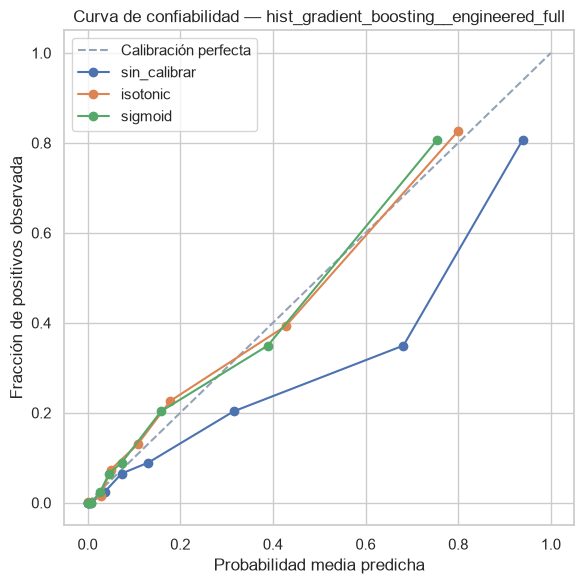

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="#94a3b8", label="Calibración perfecta")
for name, probabilities in calibrated_probabilities.items():
    fraction_positive, mean_predicted = calibration_curve(
        y_validation_check, probabilities, n_bins=10, strategy="quantile"
    )
    ax.plot(mean_predicted, fraction_positive, marker="o", label=name)
ax.set(
    title=f"Curva de confiabilidad — {champion_row_r2['run_name']}",
    xlabel="Probabilidad media predicha",
    ylabel="Fracción de positivos observada",
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "calibration_reliability_diagram.png", dpi=150)
plt.show()


In [10]:
best_calibration_name = min(("isotonic", "sigmoid"), key=lambda name: calibration_report[name]["brier_score"])
if calibration_report[best_calibration_name]["brier_score"] < calibration_report["sin_calibrar"]["brier_score"]:
    calibrated_run_name = f"calibrated_{best_calibration_name}__{champion_row_r2['run_name']}"
    calibrated_threshold = select_f1_threshold(
        y_validation_check.to_numpy(), calibrated_probabilities[best_calibration_name]
    )
    MODEL_REGISTRY[calibrated_run_name] = {
        "kind": "calibrated",
        "feature_set": champion_row_r2["feature_set"],
        "object": calibrators[best_calibration_name],
        "base_kind": champion_entry_r2["kind"],
    }
    _log_candidate(
        calibrated_run_name,
        {
            "family": "calibrated",
            "model": f"{best_calibration_name}({champion_row_r2['model']})",
            "feature_set": champion_row_r2["feature_set"],
            "base_run": champion_row_r2["run_name"],
            "calibration_method": best_calibration_name,
            "evaluated_on": "validation_check_half",
        },
        calibration_report[best_calibration_name],
        calibrated_threshold,
    )
    print(f"Calibración {best_calibration_name!r} mejora el Brier score; registrada como {calibrated_run_name!r}.")
else:
    print("Ninguna calibración mejora el Brier score del modelo base; no se registra variante calibrada.")


Calibración 'sigmoid' mejora el Brier score; registrada como 'calibrated_sigmoid__hist_gradient_boosting__engineered_full'.


## Análisis de costo: umbrales alternativos a F1

El umbral que maximiza F1 pondera precision y recall por igual. En un caso
de negocio real, el costo de un falso negativo (no detectar una sesión que
sí iba a comprar) probablemente no es igual al de un falso positivo
(gastar una acción comercial en alguien que no iba a comprar). Este
proyecto no tiene costos reales provistos, así que aquí solo se ilustra
—con supuestos explícitos e ilustrativos, no derivados de datos de
negocio— cómo cambiaría el umbral óptimo bajo distintas razones
costo_fn : costo_fp, usando las probabilidades del campeón de esta ronda en
`validation_check` (la misma mitad usada para evaluar la calibración, no la
usada para ajustarla).


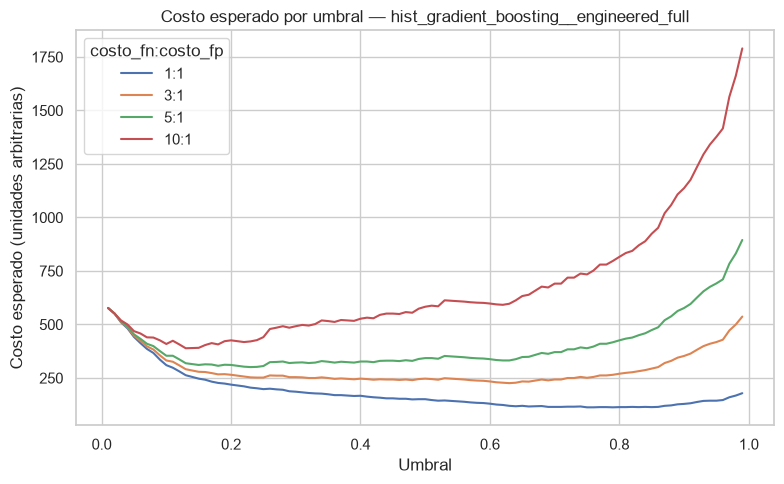

,costo_fn:costo_fp,umbral_optimo,precision,recall,f1
0,1:1,0.75,0.733333,0.636842,0.681690
1,3:1,0.63,0.671569,0.721053,0.695431
2,5:1,0.23,0.478386,0.873684,0.618250
3,10:1,0.13,0.414118,0.926316,0.572358


In [11]:
COST_RATIOS = [1, 3, 5, 10]  # costo_fn / costo_fp asumido, ilustrativo


def cost_optimal_threshold(y_true, probabilities, cost_fn, cost_fp, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
    costs = []
    for threshold in thresholds:
        predictions = probabilities >= threshold
        false_negative = int(((~predictions) & y_true).sum())
        false_positive = int((predictions & (~y_true)).sum())
        costs.append(cost_fn * false_negative + cost_fp * false_positive)
    costs_array = np.array(costs)
    best_index = int(np.argmin(costs_array))
    return float(thresholds[best_index]), thresholds, costs_array


y_true_check = y_validation_check.to_numpy().astype(bool)
champion_probabilities_check = uncalibrated_probabilities

cost_rows = []
fig, ax = plt.subplots(figsize=(8, 5))
for cost_fn in COST_RATIOS:
    threshold, thresholds, costs = cost_optimal_threshold(
        y_true_check, champion_probabilities_check, cost_fn=cost_fn, cost_fp=1
    )
    metrics_at_threshold = evaluate_probabilities(y_validation_check, champion_probabilities_check, threshold)
    cost_rows.append(
        {
            "costo_fn:costo_fp": f"{cost_fn}:1",
            "umbral_optimo": round(threshold, 3),
            "precision": metrics_at_threshold["precision"],
            "recall": metrics_at_threshold["recall"],
            "f1": metrics_at_threshold["f1"],
        }
    )
    ax.plot(thresholds, costs, label=f"{cost_fn}:1")

ax.set(
    title=f"Costo esperado por umbral — {champion_row_r2['run_name']}",
    xlabel="Umbral",
    ylabel="Costo esperado (unidades arbitrarias)",
)
ax.legend(title="costo_fn:costo_fp")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cost_sensitivity_thresholds.png", dpi=150)
plt.show()

pd.DataFrame(cost_rows)


## Selección final (ronda 2) y comparación global

Se compara el mejor candidato de esta ronda contra el campeón registrado en
`03_model_experiments.ipynb`. Solo si lo supera en F1 de **validación** se
evalúa sobre test (una segunda mirada al test, ver la nota al inicio del
notebook); si no, el test no se vuelve a tocar.

La familia `calibrated` se excluye de esta comparación puntual: su F1 se
calculó sobre `validation_check` (la mitad de validación reservada para
medir la calibración), mientras que el resto de candidatos se evaluó sobre
la validación completa. Mezclar ambos F1 no sería una comparación justa
(tamaños de muestra distintos). El beneficio de la calibración (mejor Brier
score) ya quedó documentado en el experimento D con una comparación
internamente consistente.


In [12]:
ranked_round2 = ranked_results()
ranked_round2 = ranked_round2[ranked_round2["family"] != "calibrated"].reset_index(drop=True)
best_round2 = ranked_round2.iloc[0]

comparison_round2 = pd.DataFrame(
    {
        "campeón notebook 03": {
            "modelo": previous_champion_run,
            "f1_validation": previous_validation_f1,
        },
        "mejor candidato ronda 2": {
            "modelo": best_round2["run_name"],
            "f1_validation": float(best_round2["f1"]),
        },
    }
).T
comparison_round2


,modelo,f1_validation
campeón notebook 03,stacking_trees__engineered_full,0.686327
mejor candidato ronda 2,hist_gradient_boosting__engineered_full,0.68593


In [13]:
round2_test_metrics = None
if float(best_round2["f1"]) > previous_validation_f1:
    print(
        "El mejor candidato de esta ronda supera al campeón de 03 en F1 de validación; "
        "se evalúa una única vez en test (segunda mirada de la serie de notebooks; "
        "tratar como informativo)."
    )
    round2_test_probabilities = predict_proba_for_run(best_round2["run_name"], test_fe)
    round2_test_metrics = evaluate_probabilities(
        y_test, round2_test_probabilities, float(best_round2["threshold"])
    )
    with tracked_run(
        tracking_uri=TRACKING_URI,
        experiment_name=EXPERIMENT_NAME,
        run_name="experiment_champion_v2",
        params={
            "candidate": best_round2["run_name"],
            "family": best_round2["family"],
            "note": "segunda_mirada_a_test_informativa",
        },
    ):
        mlflow.log_metrics({f"test_{key}": float(value) for key, value in round2_test_metrics.items()})
        mlflow.log_metric("threshold", float(best_round2["threshold"]))
        mlflow.set_tag(
            "note",
            "segunda evaluacion de test en la serie de notebooks; no promueve automaticamente a produccion",
        )
else:
    print("Ningún candidato de esta ronda supera al campeón de 03 en F1 de validación; el test no se vuelve a tocar.")

round2_test_metrics


Ningún candidato de esta ronda supera al campeón de 03 en F1 de validación; el test no se vuelve a tocar.


In [14]:
production_metrics = json.loads(PRODUCTION_METRICS_PATH.read_text())
comparison_rows = {
    "producción (champion actual)": {
        "modelo": production_metrics["champion"],
        "f1_validation": production_metrics["validation"]["f1"],
        "f1_test": production_metrics["test"]["f1"],
    },
    "notebook 03 (ronda 1)": {
        "modelo": previous_champion_run,
        "f1_validation": previous_validation_f1,
        "f1_test": previous_test_f1,
    },
    "notebook 04 (ronda 2)": {
        "modelo": best_round2["run_name"],
        "f1_validation": float(best_round2["f1"]),
        "f1_test": round2_test_metrics["f1"] if round2_test_metrics is not None else None,
    },
}
pd.DataFrame(comparison_rows).T


,modelo,f1_validation,f1_test
producción (champion actual),random_forest__with_page_values,0.671815,0.673469
notebook 03 (ronda 1),stacking_trees__engineered_full,0.686327,0.673797
notebook 04 (ronda 2),hist_gradient_boosting__engineered_full,0.68593,None


## Conclusiones

- Se sumaron XGBoost y LightGBM (categóricas nativas, sin one-hot) a las
  familias de árboles ya exploradas (Random Forest, Extra Trees, Gradient
  Boosting, HistGradientBoosting, CatBoost).
- El ajuste de hiperparámetros pasó de un barrido manual sobre un único
  split (notebook 03) a `RandomizedSearchCV` con validación cruzada de 5
  *folds* para HistGradientBoosting, XGBoost y LightGBM, y a una búsqueda
  manual equivalente por *k-fold* para CatBoost.
- CatBoost con Focal Loss se comparó directamente contra
  `auto_class_weights="Balanced"` como estrategia de desbalance de clases,
  bajo el mismo conjunto de variables.
- La calibración (isotónica/sigmoide) del mejor candidato se evaluó con
  Brier score y curva de confiabilidad, usando una mitad de validación para
  calibrar y la otra para medir, evitando reutilizar los mismos datos.
- El análisis de costo muestra, bajo supuestos explícitamente ilustrativos,
  cuánto se movería el umbral óptimo si un falso negativo constituyera un
  costo varias veces mayor que un falso positivo — útil como insumo para
  una conversación de negocio, no como una recomendación de umbral final.
- Como en la ronda 1, no se probaron arquitecturas fuera del alcance
  pedido (redes neuronales u otros enfoques de deep learning).
- Si `notebook 04 (ronda 2)` superó de forma consistente al champion de
  producción (no solo por varianza), el siguiente paso es promoverlo:
  incorporar esa combinación de modelo + variables a
  `online_shoppers.modeling.build_candidate_pipelines` y volver a correr el
  pipeline controlado de `02_model_training.ipynb`, que es el único que
  escribe `models/champion.joblib`. Antes de promover, conviene revisar de
  nuevo el resultado de test con una evaluación fresca (un solo vistazo),
  ya que aquí el test pudo mirarse más de una vez a lo largo de la serie de
  notebooks.
